In [2]:
from pprint import pprint
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Sources: <br>
* SILVERMAN, Density Estimation for Statistics and Data Analysis <br>
* WAND, Kernel Smoothing <br>
* WASSERMAN, All of Nonparametric Statistics

# Histograms

In [85]:
import numpy as np

def histogram(
    x: np.ndarray, 
    binwidth: float
) -> list:
    n = len(x)
    # Align the start to the floor of the minimum value
    x_min = np.floor(x.min())
    x_max = np.ceil(x.max())
    
    # Create the edges of the bins
    # We use arange to ensure each step is exactly 'binwidth'
    grid = np.arange(x_min, x_max + binwidth, binwidth)
    
    hist_values = []
    
    # Iterate through the grid to create adjacent bins
    for i in range(len(grid) - 1):
        bin_start = grid[i]
        bin_end = grid[i+1]
        
        # Count points in the current bin [start, end)
        count = np.sum((x >= bin_start) & (x < bin_end))
        
        # Calculate density: f_hat = count / (n * h)
        f_hat = count / (n * binwidth)
        
        # Store as (bin_range_tuple, density)
        hist_values.append(f_hat)

    return grid, hist_values

In [ ]:
grid, hist = histogram(
    x = np.array([1.5, 1.7, 1.8, 1.9, 3, 4.9, 5.1]),
    binwidth = 0.5
    )

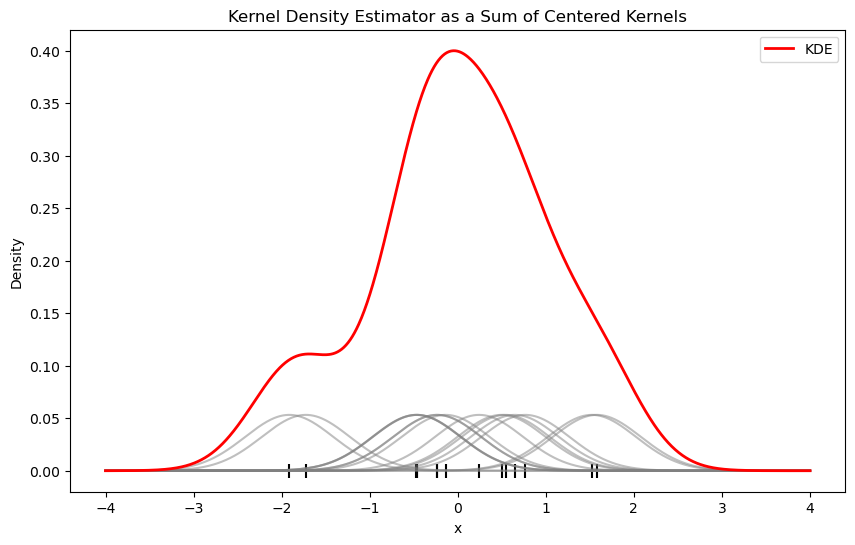

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------
# Sample data
# ---------------------------
np.random.seed(42)
X = np.random.normal(loc=0, scale=1, size=15)
n = len(X)

# ---------------------------
# Parameters
# ---------------------------
h = 0.5  # bandwidth
x_grid = np.linspace(-4, 4, 1000)

# ---------------------------
# Gaussian kernel function
# ---------------------------
def gaussian_kernel(u):
    return norm.pdf(u)  # standard normal kernel

# ---------------------------
# Compute individual kernels
# ---------------------------
kernels = []

for xi in X:
    k = (1 / h) * gaussian_kernel((x_grid - xi) / h)
    kernels.append(k)

kernels = np.array(kernels)

# ---------------------------
# Compute KDE as average
# ---------------------------
kde = (1 / n) * np.sum(kernels, axis=0)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# Plot individual centered kernels
for i in range(n):
    plt.plot(x_grid, kernels[i] / n, color='gray', alpha=0.5)

# Plot final KDE
plt.plot(x_grid, kde, color='red', linewidth=2, label='KDE')

# Rug plot
plt.scatter(X, np.zeros_like(X), marker='|', color='black', s=100)

plt.title("Kernel Density Estimator as a Sum of Centered Kernels")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

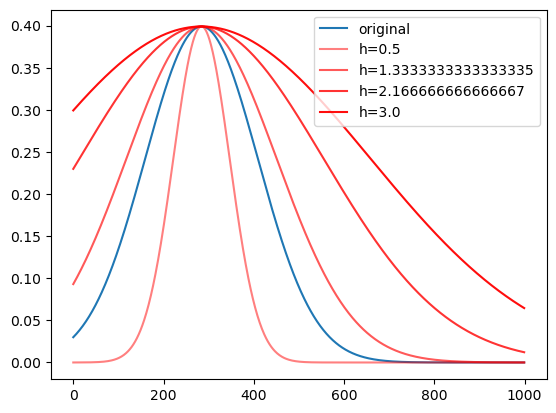

In [114]:
plt.figure()

plt.plot(
    norm.pdf(
        (x_grid - xi)
        )
    , label="original"
    )

# plt.plot(
#     norm.pdf(
#         (x_grid - xi)/h
#         )
#     , label="weighed"
#     )

# plt.plot(
#     norm.pdf(
#         (x_grid - xi)/h
#         )/h
#     , label="weighed_2"
#     )

alpha0 = 0.5
for h in np.linspace(0.5, 3, 4):
    plt.plot(
        norm.pdf(
            (x_grid - xi)/h
            )
        , label=f"h={h}"
        , color="red"
        , alpha=alpha0
        )
    
    alpha0 += 0.15

plt.legend()
plt.show()

In [ ]:
# Kernel-dependent constants for bandwidth selection
K_GAUSSIAN_SCOTT = 1.06
K_GAUSSIAN_SILVERMAN = 0.9
K_EPANECHNIKOV_SCOTT = 2.34

KERNEL_CONSTANTS = {
    "gaussian": {
        "scott":     K_GAUSSIAN_SCOTT,
        "silverman": K_GAUSSIAN_SILVERMAN,
    },
    "epanechnikov": {
        "scott":     K_EPANECHNIKOV_SCOTT,
        "silverman": K_GAUSSIAN_SILVERMAN * K_EPANECHNIKOV_SCOTT / K_GAUSSIAN_SCOTT # scaled to preserve Silverman/Gaussian ratio
    },
}
display(pd.DataFrame(KERNEL_CONSTANTS))

,gaussian,epanechnikov
scott,1.06,2.340000
silverman,0.90,1.986792
